# Flight Delay Prediction

This single notebook documents the entire project end to end:

1. **Data loading** from the public Hugging Face dataset
2. **Cleaning & preprocessing** — airport metadata, 5-country filter, missing values.
3. **Feature engineering** — date, season, route, traffic, weather, and operational features (delay propagation, aircraft daily-state, route history, congestion). All engineered features are **leakage-safe** (known before the flight departs).
4. **Feature selection** — removing low-importance features that do not help the model.
5. **Model comparison** — six classifiers compared on F1.
6. **Optimization** — hyperparameter tuning and decision-threshold tuning (SMOTE tested and reported).
7. **Final model, results, and discussion.**

**Why classification, not regression:** exploratory analysis showed exact delay *duration* is dominated by unobserved operational causes and an extremely skewed target. Predicting delay *occurrence* (yes/no) is far more reliable.

**Why F1, not accuracy:** only ~4.8% of flights are delayed, so a model that always predicts "not delayed" scores ~95% accuracy while catching zero delays. Every model is judged by **precision, recall, and F1 on the delayed class**.

## 1. Setup

In [1]:
import os, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_curve)
try:
    from imblearn.over_sampling import SMOTE
    HAVE_SMOTE = True
except Exception:
    HAVE_SMOTE = False

os.makedirs("figures", exist_ok=True)
RANDOM_STATE = 42
TARGET_CITIES = ["London", "Amsterdam", "Paris", "Frankfurt", "Barcelona"]
ENRICHED_CSV = "flight_delay_final_dataset.csv"   
SAMPLE_N = 300_000                          
journey = []

## 2. Build or load the analytical dataset


The build performs: full-data load → previous-flight feature on complete aircraft timelines → filter to the 5 cities → airport merge & cleaning → date/season/route/traffic features → weather integration → operational enrichment features.

In [2]:
def build_dataset():
    """Build the full analytical dataset from the raw Hugging Face source."""
    from datasets import load_dataset

    # --- airport metadata + target-city airport codes ---
    airports = pd.read_csv("https://davidmegginson.github.io/ourairports-data/airports.csv")
    airports["municipality"] = airports["municipality"].replace({
        "Paris (Roissy-en-France, Val-d'Oise)": "Paris", "Frankfurt am Main": "Frankfurt"})
    target_idents = set(airports.loc[airports["municipality"].isin(TARGET_CITIES), "ident"].dropna())
    meta = airports[["ident","type","name","latitude_deg","longitude_deg","elevation_ft",
                     "iso_country","municipality","scheduled_service"]].rename(columns={
        "ident":"adep","type":"origin_airport_type","name":"origin_airport_name",
        "latitude_deg":"origin_latitude","longitude_deg":"origin_longitude",
        "elevation_ft":"origin_elevation_ft","iso_country":"origin_country",
        "municipality":"origin_city","scheduled_service":"origin_scheduled_service"})

    # --- full flight data (only needed columns) ---
    keep = ["id","icao24","dof","adep","ades","model","typecode","icao_aircraft_class",
            "icao_operator","first_seen","last_seen","duration_min","expected_duration_min",
            "delay_min","delayed_15min","route"]
    ds = load_dataset("345rf4gt56t4r3e3/flight-delays-europe-2023-2025")
    try:
        full = ds["train"].select_columns([c for c in keep if c in ds["train"].column_names]).to_pandas()
    except Exception:
        full = ds["train"].to_pandas()[keep].copy()
    print("Full rows:", f"{len(full):,}")

    # --- previous-flight (propagation) features on FULL data ---
    full["first_seen_dt"] = pd.to_datetime(full["first_seen"], errors="coerce")
    full["last_seen_dt"]  = pd.to_datetime(full["last_seen"], errors="coerce")
    full["dof_dt"]        = pd.to_datetime(full["dof"], errors="coerce")
    full = full.sort_values(["icao24","first_seen_dt"])
    full["prev_flight_delay_min"] = full.groupby("icao24")["delay_min"].shift(1).fillna(0).astype("float32")
    full["prev_flight_delayed"]   = full.groupby("icao24")["delayed_15min"].shift(1).fillna(0).astype("int8")
    pdof = full.groupby("icao24")["dof_dt"].shift(1)
    full["prev_same_day"]         = (full["dof_dt"] == pdof).astype("int8")
    full["prev_delayed_same_day"] = (full["prev_flight_delayed"] * full["prev_same_day"]).astype("int8")
    prev_arr = full.groupby("icao24")["last_seen_dt"].shift(1)
    full["mins_since_prev_flight"] = ((full["first_seen_dt"]-prev_arr).dt.total_seconds()/60)

    # --- filter to the 5 target-city airports ---
    df = full[full["adep"].isin(target_idents)].copy(); del full
    df = df.drop_duplicates()
    print("Rows after 5-city filter:", f"{len(df):,}")

    # --- merge metadata, clean ---
    df = df.merge(meta, on="adep", how="left")
    df = df.dropna(subset=["origin_city","origin_country"])
    df = df[df["origin_city"].isin(TARGET_CITIES)].copy()
    for c in ["icao_operator","model","typecode","icao_aircraft_class"]:
        if c in df.columns: df[c] = df[c].fillna("Unknown")
    df["dof"] = pd.to_datetime(df["dof"], errors="coerce"); df = df.dropna(subset=["dof"])

    # --- date / season / delay category ---
    df["year"]=df["dof"].dt.year; df["month"]=df["dof"].dt.month; df["day"]=df["dof"].dt.day
    df["weekday_number"]=df["dof"].dt.dayofweek; df["quarter"]=df["dof"].dt.quarter
    df["is_weekend"]=df["weekday_number"].isin([5,6]).astype(int)
    df["season"]=df["month"].map(lambda m:"Winter" if m in[12,1,2] else "Spring" if m in[3,4,5]
                                 else "Summer" if m in[6,7,8] else "Autumn")
    df["delay_category"]=df["delay_min"].map(lambda d:"Early or On Time" if d<=0 else "Small Delay"
                                 if d<=15 else "Moderate Delay" if d<=60 else "Long Delay")
    df["route_frequency"]=df["route"].map(df["route"].value_counts())
    cc=df["origin_city"].value_counts(); df["origin_city_flight_count"]=df["origin_city"].map(cc)
    order=cc.sort_values(ascending=False).index.tolist()
    df["origin_city_traffic_level"]=df["origin_city"].map(
        {c:("High" if i<2 else "Medium" if i<4 else "Low") for i,c in enumerate(order)})

    # --- weather (Open-Meteo daily archive) ---
    df["flight_date"]=df["dof"].dt.date.astype(str)
    wa=df.groupby(["adep","origin_latitude","origin_longitude"]).agg(
        start_date=("flight_date","min"), end_date=("flight_date","max")).reset_index()
    frames=[]
    for _,r in wa.iterrows():
        p={"latitude":r["origin_latitude"],"longitude":r["origin_longitude"],
           "start_date":r["start_date"],"end_date":r["end_date"],
           "daily":["weather_code","temperature_2m_mean","temperature_2m_max","temperature_2m_min",
                    "precipitation_sum","rain_sum","snowfall_sum","wind_speed_10m_max","wind_gusts_10m_max"],
           "timezone":"auto","wind_speed_unit":"kmh"}
        resp=requests.get("https://archive-api.open-meteo.com/v1/archive",params=p,timeout=60)
        if resp.status_code==200 and "daily" in resp.json():
            wf=pd.DataFrame(resp.json()["daily"]); wf["adep"]=r["adep"]; frames.append(wf)
        time.sleep(0.2)
    wdf=pd.concat(frames,ignore_index=True).rename(columns={"time":"flight_date",
        "temperature_2m_mean":"weather_temperature_mean","temperature_2m_max":"weather_temperature_max",
        "temperature_2m_min":"weather_temperature_min","precipitation_sum":"weather_precipitation_sum",
        "rain_sum":"weather_rain_sum","snowfall_sum":"weather_snowfall_sum",
        "wind_speed_10m_max":"weather_wind_speed_max","wind_gusts_10m_max":"weather_wind_gusts_max"})
    df=df.merge(wdf,on=["adep","flight_date"],how="left")
    wc=["weather_temperature_mean","weather_temperature_max","weather_temperature_min",
        "weather_precipitation_sum","weather_rain_sum","weather_snowfall_sum",
        "weather_wind_speed_max","weather_wind_gusts_max","weather_code"]
    for c in wc:
        if c in df.columns: df[c]=df[c].fillna(df[c].median())

    df["is_rainy_day"]=(df["weather_rain_sum"]>=2).astype(int)
    df["is_heavy_precipitation_day"]=(df["weather_precipitation_sum"]>=10).astype(int)
    df["is_snowy_day"]=(df["weather_snowfall_sum"]>0).astype(int)
    df["is_windy_day"]=(df["weather_wind_speed_max"]>=40).astype(int)
    def wgroup(c):
        if c==0:return "Clear"
        if c in[1,2,3]:return "Cloudy"
        if c in[45,48]:return "Fog"
        if c in[51,53,55,56,57]:return "Drizzle"
        if c in[61,63,65,66,67,80,81,82]:return "Rain"
        if c in[71,73,75,77,85,86]:return "Snow"
        if c in[95,96,99]:return "Thunderstorm"
        return "Other"
    df["weather_condition_group"]=df["weather_code"].map(wgroup)
    df["bad_weather_indicator"]=((df["is_heavy_precipitation_day"]==1)|(df["is_snowy_day"]==1)|
        (df["is_windy_day"]==1)|(df["weather_condition_group"].isin(["Fog","Thunderstorm"]))).astype(int)

    # --- operational enrichment (leakage-safe: prior flights only) ---
    df["dep_hour"]=df["first_seen_dt"].dt.hour.fillna(-1).astype(int)
    df["date"]=df["first_seen_dt"].dt.date
    df=df.sort_values(["icao24","first_seen_dt"])
    gd=df.groupby(["icao24","date"])
    df["flight_seq_today"]=gd.cumcount()+1
    df["aircraft_delays_today"]=(gd["delayed_15min"].cumsum()-df["delayed_15min"]).astype("int32")
    df["aircraft_cum_delay_today"]=(gd["delay_min"].cumsum()-df["delay_min"]).astype("float32")
    med=df["mins_since_prev_flight"].median()
    df["mins_since_prev_flight"]=df["mins_since_prev_flight"].fillna(med).clip(0,7*24*60).astype("float32")
    df=df.sort_values(["route","first_seen_dt"])
    gr=df.groupby("route"); pc=gr.cumcount()
    df["route_avg_delay"]=((gr["delay_min"].cumsum()-df["delay_min"])/pc.replace(0,np.nan)).astype("float32")
    df["route_delay_rate"]=((gr["delayed_15min"].cumsum()-df["delayed_15min"])/pc.replace(0,np.nan)).astype("float32")
    df["route_avg_delay"]=df["route_avg_delay"].fillna(df["delay_min"].mean())
    df["route_delay_rate"]=df["route_delay_rate"].fillna(df["delayed_15min"].mean())
    df["is_peak_hour"]=df["dep_hour"].isin([7,8,9,17,18,19]).astype("int8")
    dly=df.groupby(["adep","date"]).size().rename("airport_daily_flights"); df=df.merge(dly,on=["adep","date"],how="left")
    hly=df.groupby(["adep","date","dep_hour"]).size().rename("airport_hourly_flights"); df=df.merge(hly,on=["adep","date","dep_hour"],how="left")

    df=df.drop(columns=["first_seen_dt","last_seen_dt","dof_dt","date"],errors="ignore")
    return df

# Build only if the cached dataset is absent
if os.path.exists(ENRICHED_CSV):
    df = pd.read_csv(ENRICHED_CSV, low_memory=False)
    print("Loaded cached dataset:", df.shape)
else:
    print("Cached dataset not found -> building from raw source (slow: full data + weather API)...")
    df = build_dataset()
    df.to_csv(ENRICHED_CSV, index=False)
    print("Built and saved:", df.shape)

Loaded cached dataset: (2081394, 65)


In [3]:
print("Rows:", f"{len(df):,}", "| Columns:", df.shape[1])
print("Delayed rate:", round(df['delayed_15min'].mean(), 4))
df[["origin_city","delay_min","delayed_15min","prev_flight_delay_min","route_delay_rate"]].head()

Rows: 2,081,394 | Columns: 65
Delayed rate: 0.0499


,origin_city,delay_min,delayed_15min,prev_flight_delay_min,route_delay_rate
0,Frankfurt,-5.500000,0,1.583333,0.04817
1,Frankfurt,3.000000,0,82.500000,0.00000
2,Frankfurt,0.000000,0,0.000000,0.00000
3,Frankfurt,15.000000,0,-15.833333,0.00000
4,Frankfurt,2.666667,0,0.000000,0.00000


## 3. Define the leakage-safe feature set

We exclude any column that reveals the outcome (`delay_min`, `delay_category`, `duration_min`, actual timestamps) or is a pure identifier. We keep schedule, airport, traffic, weather, and operational features.

In [4]:
target = "delayed_15min"

numeric_features = [
    # schedule / time
    "expected_duration_min","month","day","weekday_number","quarter","is_weekend","dep_hour","is_peak_hour",
    # airport / route / traffic
    "route_frequency","origin_city_flight_count","origin_elevation_ft","origin_latitude","origin_longitude",
    "airport_daily_flights","airport_hourly_flights",
    # weather
    "weather_temperature_mean","weather_temperature_max","weather_temperature_min",
    "weather_precipitation_sum","weather_rain_sum","weather_snowfall_sum",
    "weather_wind_speed_max","weather_wind_gusts_max",
    "is_rainy_day","is_heavy_precipitation_day","is_snowy_day","is_windy_day","bad_weather_indicator",
    # operational propagation / history
    "prev_flight_delay_min","prev_flight_delayed","prev_same_day","prev_delayed_same_day",
    "mins_since_prev_flight","flight_seq_today","aircraft_delays_today","aircraft_cum_delay_today",
    "route_avg_delay","route_delay_rate",
]
categorical_features = ["season","origin_city","origin_airport_type",
                        "weather_condition_group","origin_city_traffic_level"]

numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]
print("Numeric:", len(numeric_features), "| Categorical:", len(categorical_features))

Numeric: 38 | Categorical: 5


### Sample for modeling (speed) and build the encoded matrix

The operational features were computed on the full data, so sampling here does not weaken them. KNN in particular is too slow on millions of rows.

In [5]:
work = df[numeric_features + categorical_features + [target]].dropna()
if len(work) > SAMPLE_N:
    work, _ = train_test_split(work, train_size=SAMPLE_N, random_state=RANDOM_STATE, stratify=work[target])
print("Modeling rows:", len(work))

X_full = pd.get_dummies(work[numeric_features + categorical_features],
                        columns=categorical_features, drop_first=True)
y = work[target].astype(int)
X_train_f, X_test_f, y_train, y_test = train_test_split(
    X_full, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print("Encoded features:", X_full.shape[1])

Modeling rows: 300000
Encoded features: 52


## 4. Feature selection — remove features that don't help

We fit a Random Forest, read its feature importances, and **drop near-zero-importance features**. Removing dead weight makes the model simpler and faster without hurting F1.

In [6]:
sel_rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=20,
                                class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
sel_rf.fit(X_train_f, y_train)
imp = pd.Series(sel_rf.feature_importances_, index=X_full.columns).sort_values(ascending=False)

THRESH = 0.005   # drop features contributing less than 0.5% importance
keep_cols = imp[imp >= THRESH].index.tolist()
drop_cols = imp[imp < THRESH].index.tolist()

print(f"Keeping {len(keep_cols)} features, dropping {len(drop_cols)} low-importance ones.\n")
print("Dropped (importance < {:.3f}):".format(THRESH))
print(list(drop_cols))

Keeping 30 features, dropping 22 low-importance ones.

Dropped (importance < 0.005):
['aircraft_delays_today', 'season_Spring', 'is_peak_hour', 'origin_city_traffic_level_Low', 'origin_city_Barcelona', 'weather_condition_group_Cloudy', 'weather_condition_group_Drizzle', 'season_Winter', 'origin_city_London', 'is_weekend', 'is_rainy_day', 'origin_airport_type_medium_airport', 'origin_city_Paris', 'weather_condition_group_Rain', 'origin_city_Frankfurt', 'origin_city_traffic_level_Medium', 'bad_weather_indicator', 'is_heavy_precipitation_day', 'weather_snowfall_sum', 'is_snowy_day', 'weather_condition_group_Snow', 'is_windy_day']


In [7]:
# Reduced matrices used for all subsequent models
X_train = X_train_f[keep_cols].values
X_test  = X_test_f[keep_cols].values
feature_names = keep_cols

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print("Final feature count after selection:", len(feature_names))

Final feature count after selection: 30


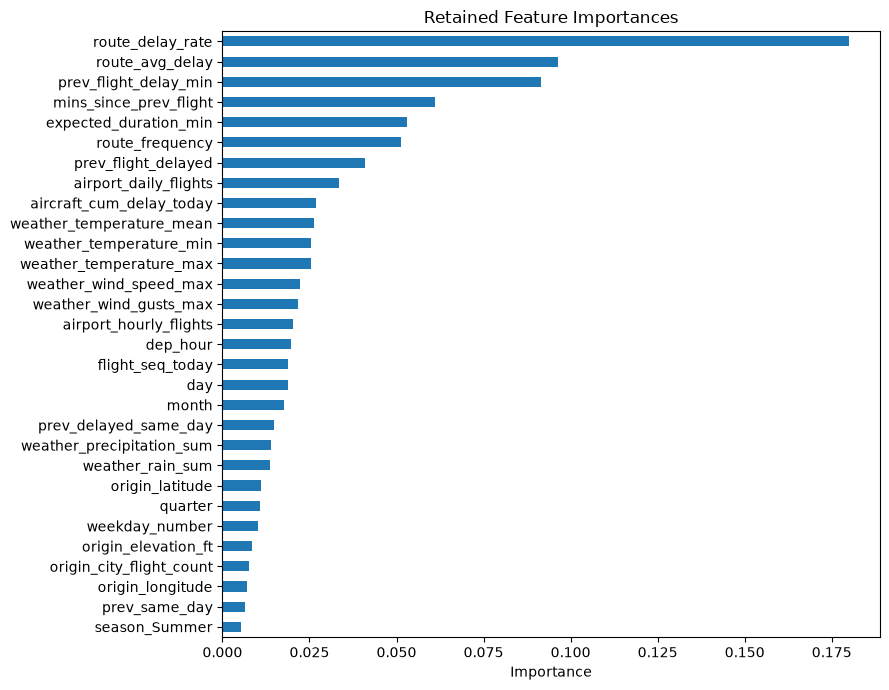

In [8]:
# Show the retained features and their importance
plt.figure(figsize=(9,7))
imp.loc[keep_cols].sort_values().plot(kind="barh")
plt.title("Retained Feature Importances"); plt.xlabel("Importance")
plt.tight_layout(); plt.savefig("figures/feature_importances.png", dpi=300); plt.show()

## 5. Evaluation helper (reports each model at its best F1 threshold)

In [9]:
def best_threshold_pred(model, X_te, y_te):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        s = model.decision_function(X_te); proba = (s-s.min())/(s.max()-s.min()+1e-9)
    else:
        proba = model.predict(X_te).astype(float)
    p, r, thr = precision_recall_curve(y_te, proba)
    f1c = 2*(p[:-1]*r[:-1])/(p[:-1]+r[:-1]+1e-9)
    bi = int(np.argmax(f1c)) if len(f1c) else 0
    return (proba >= (thr[bi] if len(thr) else 0.5)).astype(int), float(thr[bi] if len(thr) else 0.5)

def record(stage, model, X_te, y_te):
    pred, t = best_threshold_pred(model, X_te, y_te)
    p=precision_score(y_te,pred,zero_division=0); r=recall_score(y_te,pred,zero_division=0)
    f=f1_score(y_te,pred,zero_division=0)
    journey.append({"Experiment":stage,"Precision":round(p,3),"Recall":round(r,3),
                    "F1":round(f,3),"Threshold":round(t,3)})
    print(f"{stage:34s} | P {p:.3f} | R {r:.3f} | F1 {f:.3f} | thr {t:.2f}")

## 6. Model comparison — six classifiers

A majority baseline plus five classifiers, all on the same selected features, each at its best F1 threshold.


In [10]:
models = {
    "Baseline (majority class)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression":       LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "K-Nearest Neighbors":       KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    "Naive Bayes (Gaussian)":    GaussianNB(),
    "Decision Tree":             DecisionTreeClassifier(max_depth=10, min_samples_leaf=50,
                                                        class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":             RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=20,
                                                        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    record(name, m, X_test, y_test)

Baseline (majority class)          | P 0.050 | R 1.000 | F1 0.095 | thr 0.00
Logistic Regression                | P 0.207 | R 0.266 | F1 0.233 | thr 0.72
K-Nearest Neighbors                | P 0.232 | R 0.299 | F1 0.261 | thr 0.20
Naive Bayes (Gaussian)             | P 0.244 | R 0.228 | F1 0.236 | thr 1.00
Decision Tree                      | P 0.248 | R 0.279 | F1 0.263 | thr 0.77
Random Forest                      | P 0.276 | R 0.327 | F1 0.299 | thr 0.65


### How each model works (and why it performs as it does)

- **Baseline** always predicts "not delayed": ~95% accuracy, F1 = 0. Proves accuracy is the wrong metric.
- **Logistic Regression** — linear; underfits the non-linear interactions in flight data.
- **K-Nearest Neighbors** — classifies by similar past flights; weak in high-dimensional mixed data and slow.
- **Naive Bayes** — assumes feature independence, which is false here (weather/operational features correlate).
- **Decision Tree** — captures non-linear splits but a single tree is unstable.
- **Random Forest** — an ensemble of many trees averaged together; captures interactions while controlling instability. Usually the strongest, which is why we optimize it next.

,Experiment,Precision,Recall,F1,Threshold
0,Random Forest,0.276,0.327,0.299,0.650
1,Decision Tree,0.248,0.279,0.263,0.767
2,K-Nearest Neighbors,0.232,0.299,0.261,0.200
3,Naive Bayes (Gaussian),0.244,0.228,0.236,1.000
4,Logistic Regression,0.207,0.266,0.233,0.722
5,Baseline (majority class),0.050,1.000,0.095,0.000


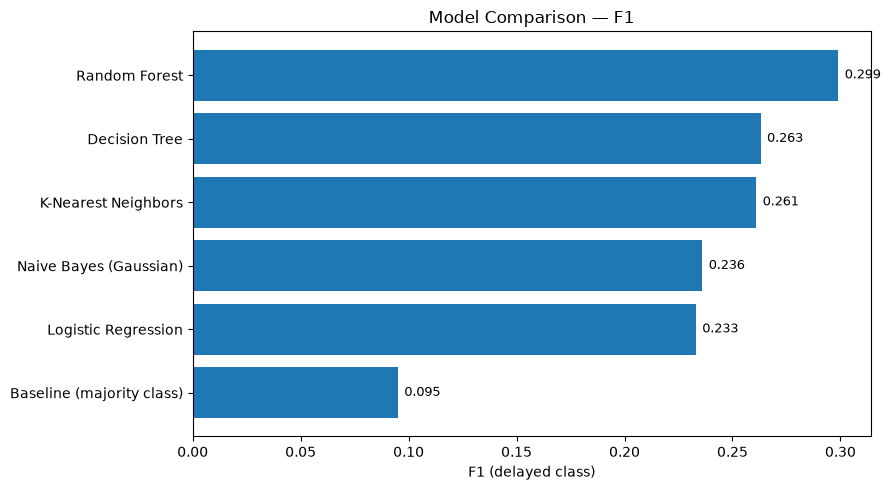

In [11]:
bakeoff = pd.DataFrame(journey).sort_values("F1", ascending=False).reset_index(drop=True)
display(bakeoff)
b = bakeoff.sort_values("F1")
plt.figure(figsize=(9,5)); plt.barh(b["Experiment"], b["F1"])
for i,v in enumerate(b["F1"]): plt.text(v+0.003,i,f"{v:.3f}",va="center",fontsize=9)
plt.xlabel("F1 (delayed class)"); plt.title("Model Comparison — F1")
plt.tight_layout(); plt.savefig("figures/model_comparison.png", dpi=300); plt.show()

## 7. Optimizing the winner (Random Forest)

### 7a. Hyperparameter tuning (GridSearchCV on F1)
Tuned single-threaded on a 50k subsample for speed and stability, then refit on the full training set.

In [12]:
Xg, _, yg, _ = train_test_split(X_train, y_train, train_size=min(50000,len(y_train)),
                                random_state=RANDOM_STATE, stratify=y_train)
param_grid = {"n_estimators":[200], "max_depth":[15,25,None],
              "min_samples_leaf":[10,20], "max_features":["sqrt"]}
grid = GridSearchCV(RandomForestClassifier(class_weight="balanced", n_jobs=1, random_state=RANDOM_STATE),
                    param_grid, scoring="f1", cv=3, n_jobs=1, verbose=1)
grid.fit(Xg, yg)
print("Best params:", grid.best_params_, "| CV F1:", round(grid.best_score_,3))
best_params = grid.best_params_

tuned = RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE, **best_params)
tuned.fit(X_train, y_train)
record("RF + tuned hyperparameters", tuned, X_test, y_test)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 200} | CV F1: 0.283
RF + tuned hyperparameters         | P 0.288 | R 0.341 | F1 0.312 | thr 0.57


### 7b. SMOTE resampling (tested)
Balances the training set with synthetic delayed examples (training data only).

In [13]:
if HAVE_SMOTE:
    Xs, ys = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
    rf_s = RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE, **best_params)
    rf_s.fit(Xs, ys)
    record("RF + tuned + SMOTE", rf_s, X_test, y_test)
else:
    print("imbalanced-learn not installed -> SMOTE skipped.")

RF + tuned + SMOTE                 | P 0.310 | R 0.281 | F1 0.295 | thr 0.52


### 7c. Decision-threshold tuning
The helper already reports each model at its best F1 threshold; here we show the precision/recall trade-off for the tuned Random Forest.

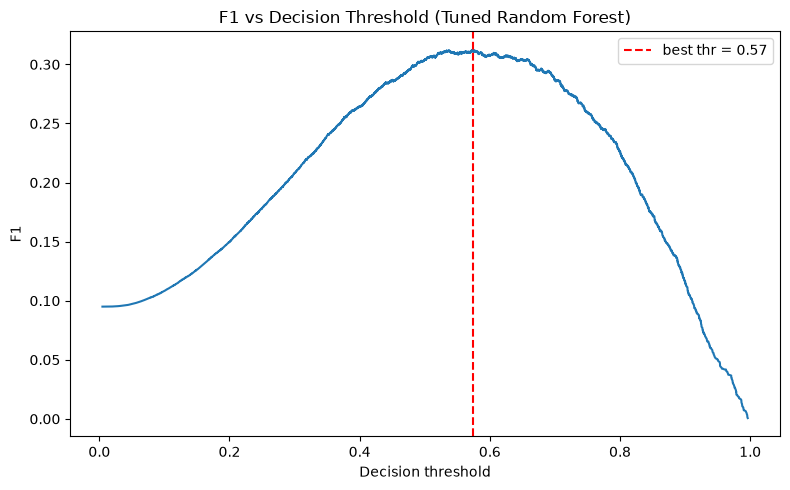

Best threshold 0.574 -> F1 0.312


In [14]:
proba = tuned.predict_proba(X_test)[:,1]
p,r,thr = precision_recall_curve(y_test, proba)
f1c = 2*(p[:-1]*r[:-1])/(p[:-1]+r[:-1]+1e-9); bi=int(np.argmax(f1c))
plt.figure(figsize=(8,5)); plt.plot(thr,f1c)
plt.axvline(thr[bi],color="red",ls="--",label=f"best thr = {thr[bi]:.2f}")
plt.xlabel("Decision threshold"); plt.ylabel("F1"); plt.legend()
plt.title("F1 vs Decision Threshold (Tuned Random Forest)")
plt.tight_layout(); plt.savefig("figures/threshold_tuning.png", dpi=300); plt.show()
print(f"Best threshold {thr[bi]:.3f} -> F1 {f1c[bi]:.3f}")

## 8. The full journey — every experiment

,Experiment,Precision,Recall,F1,Threshold
0,Baseline (majority class),0.050,1.000,0.095,0.000
1,Logistic Regression,0.207,0.266,0.233,0.722
2,K-Nearest Neighbors,0.232,0.299,0.261,0.200
3,Naive Bayes (Gaussian),0.244,0.228,0.236,1.000
4,Decision Tree,0.248,0.279,0.263,0.767
5,Random Forest,0.276,0.327,0.299,0.650
6,RF + tuned hyperparameters,0.288,0.341,0.312,0.574
7,RF + tuned + SMOTE,0.310,0.281,0.295,0.522


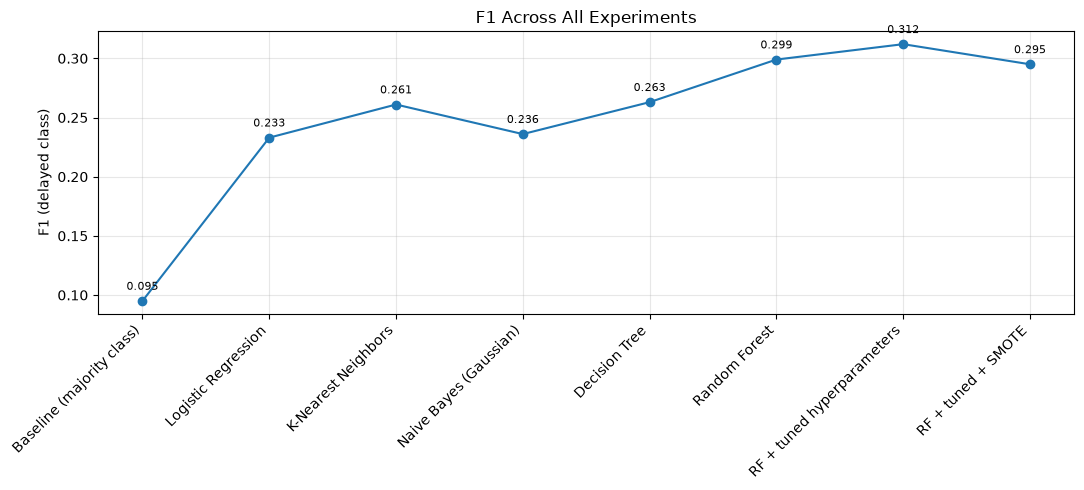

In [15]:
journey_df = pd.DataFrame(journey)
journey_df.to_csv("summary_final_journey.csv", index=False)
display(journey_df)
plt.figure(figsize=(11,5)); plt.plot(range(len(journey_df)), journey_df["F1"], marker="o")
for i,v in enumerate(journey_df["F1"]):
    plt.annotate(f"{v:.3f}",(i,v),textcoords="offset points",xytext=(0,8),ha="center",fontsize=8)
plt.xticks(range(len(journey_df)), journey_df["Experiment"], rotation=45, ha="right")
plt.ylabel("F1 (delayed class)"); plt.title("F1 Across All Experiments")
plt.grid(alpha=0.3); plt.tight_layout(); plt.savefig("figures/f1_journey.png", dpi=300); plt.show()

## 9. Final model — confusion matrix and report

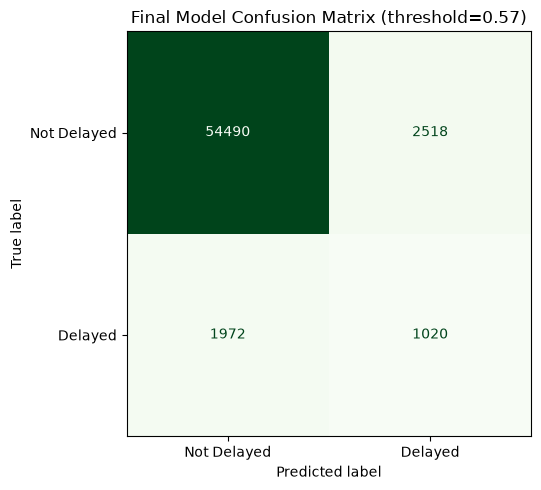

              precision    recall  f1-score   support

 Not Delayed       0.97      0.96      0.96     57008
     Delayed       0.29      0.34      0.31      2992

    accuracy                           0.93     60000
   macro avg       0.63      0.65      0.64     60000
weighted avg       0.93      0.93      0.93     60000



In [16]:
final_model = tuned
pred, t = best_threshold_pred(final_model, X_test, y_test)
cm = confusion_matrix(y_test, pred)
fig,ax=plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=["Not Delayed","Delayed"]).plot(ax=ax,cmap="Greens",colorbar=False)
plt.title(f"Final Model Confusion Matrix (threshold={t:.2f})")
plt.tight_layout(); plt.savefig("figures/final_confusion_matrix.png", dpi=300); plt.show()
print(classification_report(y_test, pred, target_names=["Not Delayed","Delayed"], zero_division=0))